Dataset grezzo: 25646 righe × 208 colonne

--- score_UCLA ---
count   24825.00
mean        5.00
std         1.85
min         3.00
25%         3.00
50%         5.00
75%         6.00
max         9.00
Name: score_UCLA, dtype: float64
Missing: 821 (3.2%)

--- intensita_sm ---
intensita_sm
0     331
1    2506
2    3488
3    5619
4    4796
5    4229
6    2688
7    1183
8     806
Name: count, dtype: int64

Media: 3.80
Missing: 0

--- Distribuzione fasce d'età ---
fascia_eta
16–34     7572
35–54    11257
55+       6802
Name: count, dtype: int64

--- Missing variabili di controllo ---
  gender              : 80 (0.3%)
  education           : 162 (0.6%)
  income_decile       : 1956 (7.6%)

--- Listwise deletion ---
Righe prima : 25646
Righe dopo  : 22962
Rimosse     : 2684 (10.5%)

=== DataFrame finale ===
Shape: (22962, 8)
Paesi presenti: 27

Anteprima:
   paese  intensita_sm  score_UCLA fascia_eta  eta  sesso  education  income
0      1             5        5.00      16–34   32   1.00       4.

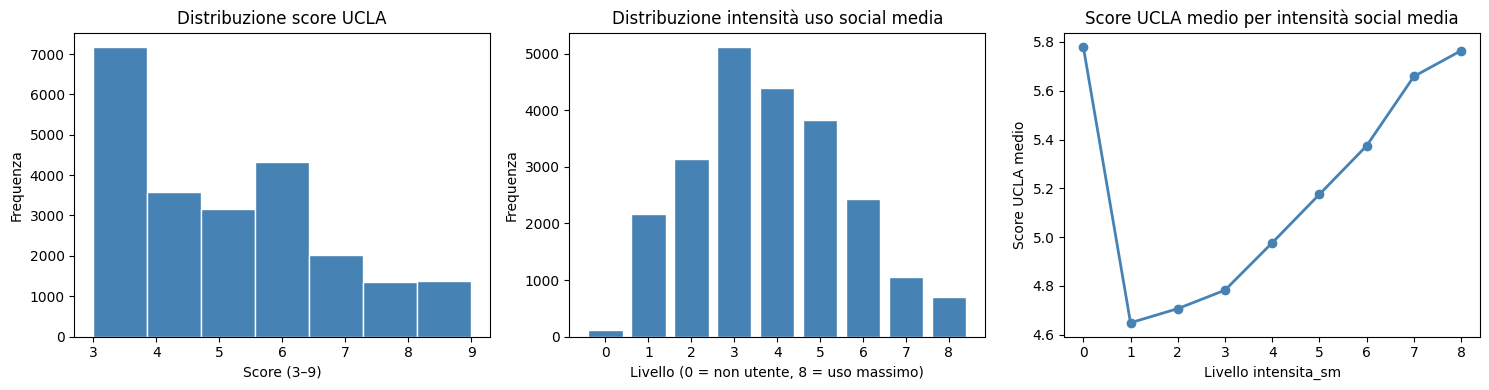


Salvato: output/dataset/eu_ls_clean.csv
Salvato: output/figures/step1_diagnostici.png


In [9]:
# ============================================================
# STEP 1 — Caricamento, pulizia e preparazione EU-LS 2022
# Does Social Media Use Reduce Loneliness?
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
 
os.makedirs('output/dataset', exist_ok=True)
os.makedirs('output/figures', exist_ok=True)
 
# ------------------------------------------------------------------
# 1.1  CARICAMENTO
# ------------------------------------------------------------------
df_raw = pd.read_csv('eu_loneliness_survey_eu27_values.csv', low_memory=False)
print(f"Dataset grezzo: {df_raw.shape[0]} righe × {df_raw.shape[1]} colonne")
 
# ------------------------------------------------------------------
# 1.2  SELEZIONE COLONNE DI INTERESSE
# ------------------------------------------------------------------
COLS = ['loneliness_ucla_a', 'loneliness_ucla_b', 'loneliness_ucla_c',
        'sm_time_a', 'country', 'age', 'gender', 'education', 'income_decile']
 
df = df_raw[COLS].copy()
 
# ------------------------------------------------------------------
# 1.3  COSTRUZIONE score_UCLA
# ------------------------------------------------------------------
for col in ['loneliness_ucla_a', 'loneliness_ucla_b', 'loneliness_ucla_c']:
    df[col] = df[col].replace(999, np.nan)
 
df['score_UCLA'] = df[['loneliness_ucla_a',
                        'loneliness_ucla_b',
                        'loneliness_ucla_c']].sum(axis=1, min_count=3)
 
print("\n--- score_UCLA ---")
print(df['score_UCLA'].describe().round(2))
print(f"Missing: {df['score_UCLA'].isna().sum()} ({df['score_UCLA'].isna().mean()*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.4  COSTRUZIONE intensita_sm
# ------------------------------------------------------------------
df['intensita_sm'] = df['sm_time_a'].replace(999, 0)
 
print("\n--- intensita_sm ---")
print(df['intensita_sm'].value_counts().sort_index())
print(f"\nMedia: {df['intensita_sm'].mean():.2f}")
print(f"Missing: {df['intensita_sm'].isna().sum()}")
 
# ------------------------------------------------------------------
# 1.5  COSTRUZIONE fascia_eta — 3 FASCE                # ← MODIFICATO
# Motivazione: la fascia 75+ (N originale ≈ 525) è troppo piccola
# per confronti robusti. Le due fasce anziane vengono accorpate
# in "55+" (N combinato ≈ 6.200), omogenea alle altre.
# La distinzione teorica rimane: nativi digitali (16–34),
# generazione di transizione (35–54), pre-digitali (55+).
# ------------------------------------------------------------------
bins   = [15, 34, 54, 120]                           # ← MODIFICATO
labels = ['16–34', '35–54', '55+']                   # ← MODIFICATO
 
df['fascia_eta'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
 
print("\n--- Distribuzione fasce d'età ---")
print(df['fascia_eta'].value_counts().sort_index())
 
# ------------------------------------------------------------------
# 1.6  PULIZIA VARIABILI DI CONTROLLO
# ------------------------------------------------------------------
for col in ['gender', 'education', 'income_decile']:
    df[col] = df[col].replace(999, np.nan)
 
print("\n--- Missing variabili di controllo ---")
for col in ['gender', 'education', 'income_decile']:
    n = df[col].isna().sum()
    print(f"  {col:20s}: {n} ({n/len(df)*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.7  LISTWISE DELETION
# ------------------------------------------------------------------
COLONNE_MODELLO = ['score_UCLA', 'intensita_sm', 'age', 'fascia_eta',
                   'gender', 'education', 'income_decile', 'country']
 
n_prima   = len(df)
df_clean  = df.dropna(subset=COLONNE_MODELLO).copy()
n_dopo    = len(df_clean)
 
print(f"\n--- Listwise deletion ---")
print(f"Righe prima : {n_prima}")
print(f"Righe dopo  : {n_dopo}")
print(f"Rimosse     : {n_prima - n_dopo} ({(n_prima - n_dopo)/n_prima*100:.1f}%)")
 
# ------------------------------------------------------------------
# 1.8  DATAFRAME FINALE
# ------------------------------------------------------------------
COLONNE_FINALI = ['country', 'intensita_sm', 'score_UCLA',
                  'fascia_eta', 'age', 'gender', 'education', 'income_decile']
 
df_final = df_clean[COLONNE_FINALI].reset_index(drop=True)
df_final.columns = ['paese', 'intensita_sm', 'score_UCLA',
                    'fascia_eta', 'eta', 'sesso', 'education', 'income']
 
print("\n=== DataFrame finale ===")
print(f"Shape: {df_final.shape}")
print(f"Paesi presenti: {df_final['paese'].nunique()}")
print(f"\nAnteprima:\n{df_final.head(5)}")
 
# ------------------------------------------------------------------
# 1.9  GRAFICI DIAGNOSTICI
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
axes[0].hist(df_final['score_UCLA'], bins=7, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione score UCLA')
axes[0].set_xlabel('Score (3–9)')
axes[0].set_ylabel('Frequenza')
 
conteggi = df_final['intensita_sm'].value_counts().sort_index()
axes[1].bar(conteggi.index, conteggi.values, color='steelblue', edgecolor='white')
axes[1].set_title('Distribuzione intensità uso social media')
axes[1].set_xlabel('Livello (0 = non utente, 8 = uso massimo)')
axes[1].set_ylabel('Frequenza')
axes[1].set_xticks(range(9))
 
medie_globali = df_final.groupby('intensita_sm')['score_UCLA'].mean()
axes[2].plot(medie_globali.index, medie_globali.values,
             marker='o', color='steelblue', linewidth=2)
axes[2].set_title('Score UCLA medio per intensità social media')
axes[2].set_xlabel('Livello intensita_sm')
axes[2].set_ylabel('Score UCLA medio')
axes[2].set_xticks(range(9))
 
plt.tight_layout()
fig.savefig('output/figures/step1_diagnostici.png', dpi=150, bbox_inches='tight')
plt.show()
 
# ------------------------------------------------------------------
# 1.10  SALVATAGGIO
# ------------------------------------------------------------------
df_final.to_csv('output/dataset/eu_ls_clean.csv', index=False)
print("\nSalvato: output/dataset/eu_ls_clean.csv")
print("Salvato: output/figures/step1_diagnostici.png")

Dataset: 22962 righe × 8 colonne

=== Statistiche per fascia d'età ===
                n  ucla_media  ucla_std  sm_media  sm_std
fascia_eta                                               
16–34        6561        5.41      1.83      4.58    1.74
35–54       10204        5.04      1.87      3.78    1.70
55+          6197        4.50      1.73      3.15    1.65

=== Statistiche per paese (ordinato per UCLA medio) ===
          n  ucla_media  sm_media
paese                            
18      322        5.47      4.38
8       883        5.37      3.99
14      905        5.35      4.25
19      448        5.35      4.46
12      919        5.34      4.24
24      921        5.29      3.86
16      860        5.11      3.97
9       893        5.11      3.75
27      887        5.08      3.77
5       451        5.06      4.35
4       917        5.06      3.82
25      910        5.06      3.59
6       905        5.05      3.57
1       878        5.04      3.32
2       879        5.01      3.54
11  

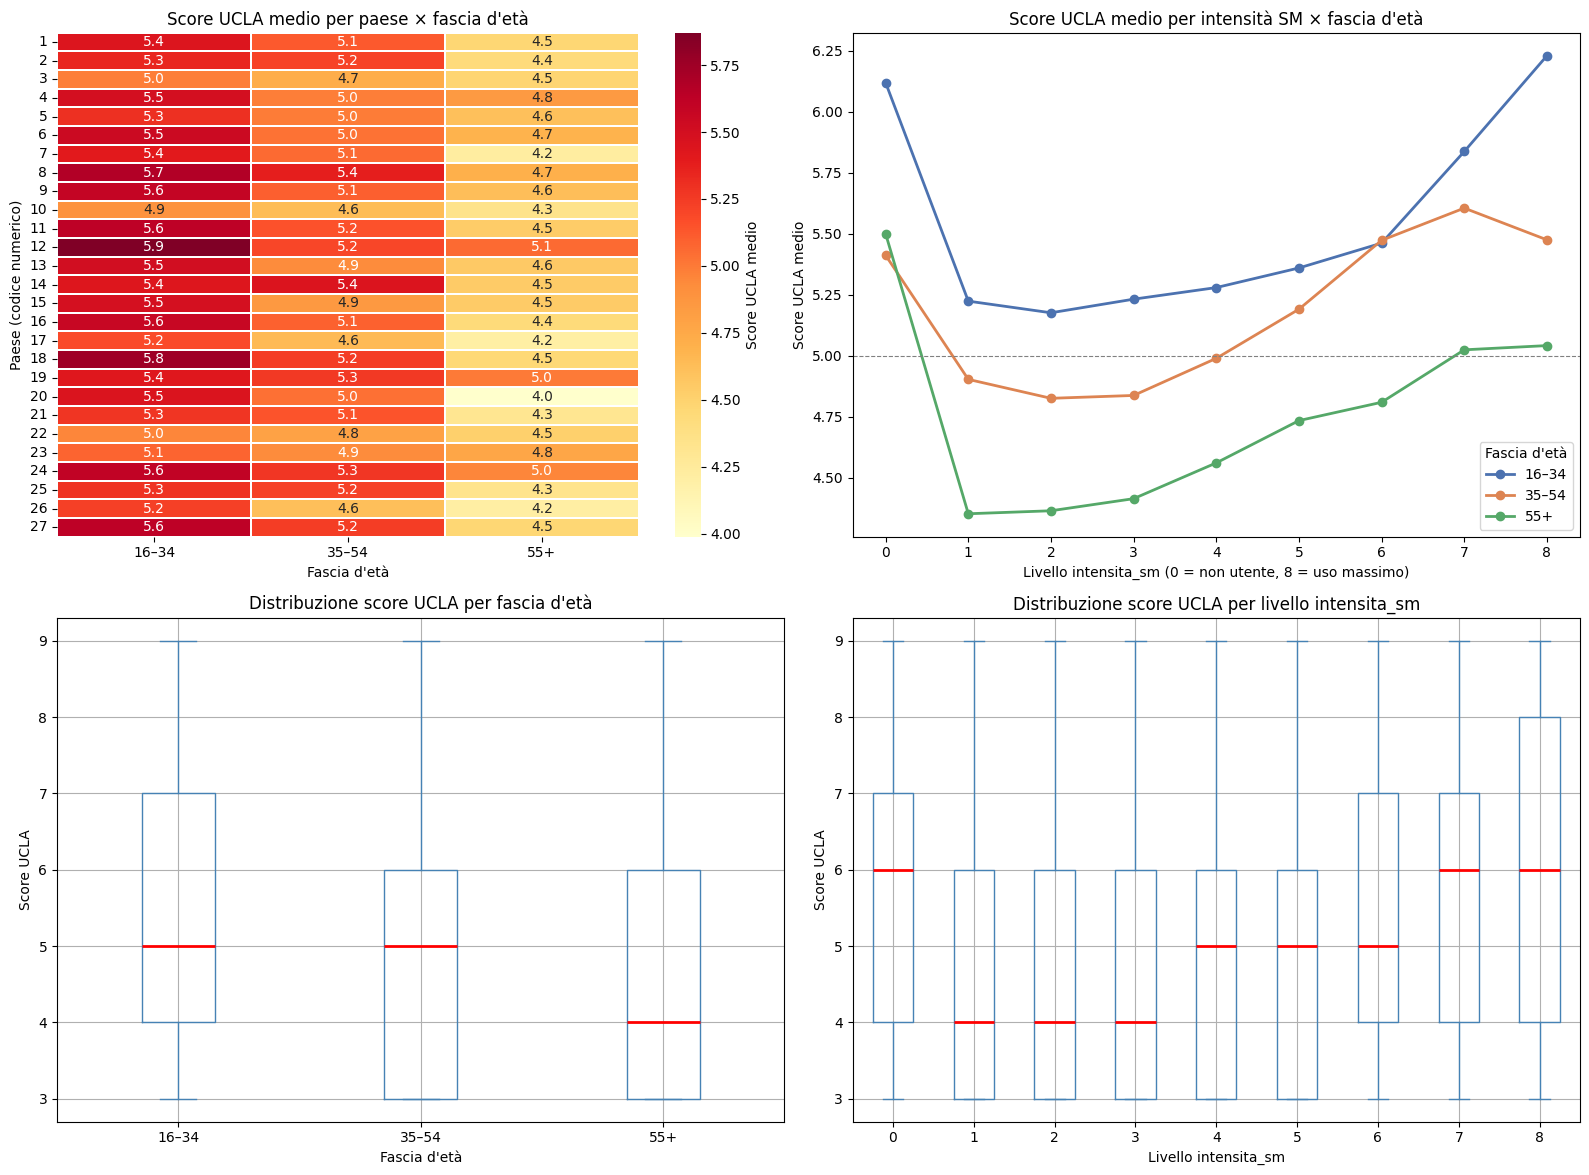


=== Riepilogo EDA ===
Score UCLA medio globale       : 5.00
Intensita_sm media globale     : 3.84
Correlazione Pearson globale   : r = 0.153 (p = 0.0000)
Correlazione Spearman globale  : r = 0.159 (p = 0.0000)

Fascia con UCLA più alto       : 16–34
Fascia con UCLA più basso      : 55+
Fascia con SM più intenso      : 16–34
Fascia con SM meno intenso     : 55+


In [10]:
# ============================================================
# STEP 2 — Analisi esplorativa (EDA)
# Does Social Media Use Reduce Loneliness?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
 
pd.set_option('display.float_format', '{:.2f}'.format)
 
# ------------------------------------------------------------------
# 2.1  CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],  # ← MODIFICATO
                                   ordered=True)
print(f"Dataset: {df.shape[0]} righe × {df.shape[1]} colonne")
 
# ------------------------------------------------------------------
# 2.2  STATISTICHE DESCRITTIVE PER FASCIA D'ETÀ
# ------------------------------------------------------------------
desc = df.groupby('fascia_eta', observed=True).agg(
    n           = ('score_UCLA', 'count'),
    ucla_media  = ('score_UCLA', 'mean'),
    ucla_std    = ('score_UCLA', 'std'),
    sm_media    = ('intensita_sm', 'mean'),
    sm_std      = ('intensita_sm', 'std'),
).round(2)
 
print("\n=== Statistiche per fascia d'età ===")
print(desc)
 
# ------------------------------------------------------------------
# 2.3  STATISTICHE DESCRITTIVE PER PAESE
# ------------------------------------------------------------------
desc_paese = df.groupby('paese', observed=True).agg(
    n          = ('score_UCLA', 'count'),
    ucla_media = ('score_UCLA', 'mean'),
    sm_media   = ('intensita_sm', 'mean'),
).round(2).sort_values('ucla_media', ascending=False)
 
print("\n=== Statistiche per paese (ordinato per UCLA medio) ===")
print(desc_paese)
 
# ------------------------------------------------------------------
# 2.4  CORRELAZIONE BIVARIATA — tutto il campione
# ------------------------------------------------------------------
pearson_r,  pearson_p  = stats.pearsonr(df['intensita_sm'], df['score_UCLA'])
spearman_r, spearman_p = stats.spearmanr(df['intensita_sm'], df['score_UCLA'])
 
print("\n=== Correlazione bivariata (tutto il campione) ===")
print(f"Pearson  r = {pearson_r:.3f}  p = {pearson_p:.4f}")
print(f"Spearman r = {spearman_r:.3f}  p = {spearman_p:.4f}")
 
# ------------------------------------------------------------------
# 2.5  CORRELAZIONE PER FASCIA D'ETÀ
# ------------------------------------------------------------------
print("\n=== Correlazione Pearson per fascia d'età ===")
corr_per_fascia = []
for fascia in ['16–34', '35–54', '55+']:                              # ← MODIFICATO
    sub = df[df['fascia_eta'] == fascia]
    r, p = stats.pearsonr(sub['intensita_sm'], sub['score_UCLA'])
    corr_per_fascia.append({'fascia': fascia, 'n': len(sub),
                            'pearson_r': round(r, 3), 'p_value': round(p, 4)})
    print(f"  {fascia:6s}  r = {r:.3f}  p = {p:.4f}  (n={len(sub)})")
 
# ------------------------------------------------------------------
# 2.6  GRAFICI EDA
# ------------------------------------------------------------------
fig = plt.figure(figsize=(16, 12))
 
# --- Fig A: Heatmap UCLA medio per paese × fascia d'età ---
ax1 = fig.add_subplot(2, 2, 1)
pivot = df.groupby(['paese', 'fascia_eta'],
                    observed=True)['score_UCLA'].mean().unstack()
sns.heatmap(pivot, ax=ax1, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.3, cbar_kws={'label': 'Score UCLA medio'})
ax1.set_title("Score UCLA medio per paese × fascia d'età")
ax1.set_xlabel("Fascia d'età")
ax1.set_ylabel('Paese (codice numerico)')
 
# --- Fig B: Line plot UCLA medio per livello intensita_sm × fascia d'età ---
ax2 = fig.add_subplot(2, 2, 2)
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'}  # ← MODIFICATO
for fascia in ['16–34', '35–54', '55+']:                              # ← MODIFICATO
    sub   = df[df['fascia_eta'] == fascia]
    medie = sub.groupby('intensita_sm')['score_UCLA'].mean()
    ax2.plot(medie.index, medie.values, marker='o', linewidth=2,
             label=fascia, color=colori[fascia])
ax2.set_title("Score UCLA medio per intensità SM × fascia d'età")
ax2.set_xlabel('Livello intensita_sm (0 = non utente, 8 = uso massimo)')
ax2.set_ylabel('Score UCLA medio')
ax2.set_xticks(range(9))
ax2.legend(title="Fascia d'età")
ax2.axhline(df['score_UCLA'].mean(), color='gray',
            linestyle='--', linewidth=0.8, label='Media globale')
 
# --- Fig C: Boxplot score UCLA per fascia d'età ---
ax3 = fig.add_subplot(2, 2, 3)
df.boxplot(column='score_UCLA', by='fascia_eta', ax=ax3,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'),
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax3.set_title("Distribuzione score UCLA per fascia d'età")
ax3.set_xlabel("Fascia d'età")
ax3.set_ylabel('Score UCLA')
plt.suptitle('')
 
# --- Fig D: Boxplot score UCLA per livello intensita_sm ---
ax4 = fig.add_subplot(2, 2, 4)
df.boxplot(column='score_UCLA', by='intensita_sm', ax=ax4,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'),
           flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax4.set_title('Distribuzione score UCLA per livello intensita_sm')
ax4.set_xlabel('Livello intensita_sm')
ax4.set_ylabel('Score UCLA')
plt.suptitle('')
 
plt.tight_layout()
fig.savefig('output/figures/step2_eda.png', dpi=150, bbox_inches='tight')
plt.show()
 
# ------------------------------------------------------------------
# 2.7  RIEPILOGO RISULTATI EDA
# ------------------------------------------------------------------
print("\n=== Riepilogo EDA ===")
print(f"Score UCLA medio globale       : {df['score_UCLA'].mean():.2f}")
print(f"Intensita_sm media globale     : {df['intensita_sm'].mean():.2f}")
print(f"Correlazione Pearson globale   : r = {pearson_r:.3f} (p = {pearson_p:.4f})")
print(f"Correlazione Spearman globale  : r = {spearman_r:.3f} (p = {spearman_p:.4f})")
print("\nFascia con UCLA più alto       :", desc['ucla_media'].idxmax())
print("Fascia con UCLA più basso      :", desc['ucla_media'].idxmin())
print("Fascia con SM più intenso      :", desc['sm_media'].idxmax())
print("Fascia con SM meno intenso     :", desc['sm_media'].idxmin())

Dataset: 22962 righe · 27 paesi

=== OLS — tutto il campione ===
N = 22962  |  R² = 0.0687  |  R² adj = 0.0674

Coefficienti chiave:
  Intercept             β= 5.0272  SE=0.0963  p=0.0000  CI=[4.8384, 5.2159]  ***
  intensita_sm          β= 0.0160  SE=0.0279  p=0.5659  CI=[-0.0387, 0.0708]  
  intensita_sm2         β= 0.0163  SE=0.0034  p=0.0000  CI=[0.0097, 0.0228]  ***
  sesso                 β= 0.1776  SE=0.0238  p=0.0000  CI=[0.1310, 0.2242]  ***
  education             β=-0.0013  SE=0.0146  p=0.9316  CI=[-0.0298, 0.0273]  
  income                β=-0.1145  SE=0.0049  p=0.0000  CI=[-0.1241, -0.1050]  ***

=== OLS — per fascia d'età ===

  Fascia 16–34  (N=6561, R²=0.0651)
    intensita_sm   β=-0.2103  p=0.0002 ***
    intensita_sm²  β=0.0347  p=0.0000 ***

  Fascia 35–54  (N=10204, R²=0.0628)
    intensita_sm   β=-0.0060  p=0.8913 n.s.
    intensita_sm²  β=0.0154  p=0.0037 **

  Fascia 55+  (N=6197, R²=0.0692)
    intensita_sm   β=0.0040  p=0.9363 n.s.
    intensita_sm²  β=0.0095 

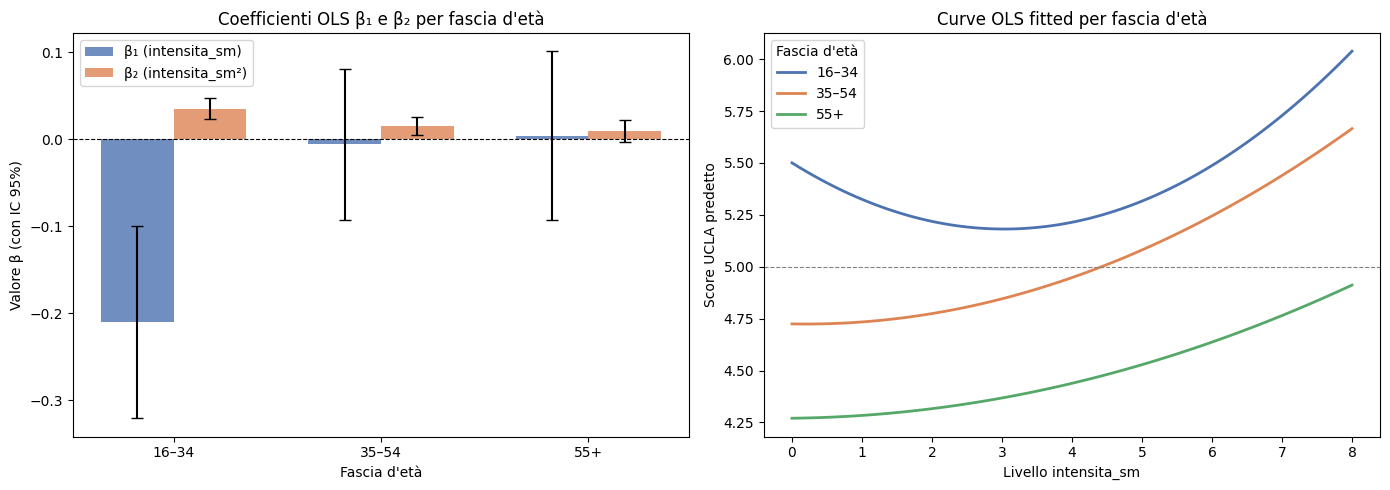

Salvato: output/figures/step3_ols.png


In [11]:
# ============================================================
# STEP 3 — Regressione OLS individuale
# Does Social Media Use Reduce Loneliness?
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from scipy import stats
 
pd.set_option('display.float_format', '{:.4f}'.format)
 
# ------------------------------------------------------------------
# 3.1  CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],  # ← MODIFICATO
                                   ordered=True)
df['intensita_sm2'] = df['intensita_sm'] ** 2
print(f"Dataset: {df.shape[0]} righe · {df['paese'].nunique()} paesi")
 
# ------------------------------------------------------------------
# 3.2  MODELLO OLS — TUTTO IL CAMPIONE
# ------------------------------------------------------------------
formula_full = ('score_UCLA ~ intensita_sm + intensita_sm2 '
                '+ sesso + education + income + C(paese)')
 
model_full = smf.ols(formula_full, data=df).fit(cov_type='HC3')
 
print("\n=== OLS — tutto il campione ===")
print(f"N = {int(model_full.nobs)}  |  R² = {model_full.rsquared:.4f}"
      f"  |  R² adj = {model_full.rsquared_adj:.4f}")
print(f"\nCoefficienti chiave:")
chiavi = ['Intercept', 'intensita_sm', 'intensita_sm2',
          'sesso', 'education', 'income']
for k in chiavi:
    b      = model_full.params[k]
    se     = model_full.bse[k]
    p      = model_full.pvalues[k]
    ci_lo, ci_hi = model_full.conf_int().loc[k]
    sig    = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"  {k:20s}  β={b:7.4f}  SE={se:.4f}  p={p:.4f}  "
          f"CI=[{ci_lo:.4f}, {ci_hi:.4f}]  {sig}")
 
# ------------------------------------------------------------------
# 3.3  MODELLO OLS — SEPARATO PER FASCIA D'ETÀ
# ------------------------------------------------------------------
fasce     = ['16–34', '35–54', '55+']                                # ← MODIFICATO
risultati = {}
 
print("\n=== OLS — per fascia d'età ===")
for fascia in fasce:
    sub = df[df['fascia_eta'] == fascia].copy()
    mod = smf.ols(formula_full, data=sub).fit(cov_type='HC3')
    risultati[fascia] = mod
 
    b1  = mod.params['intensita_sm']
    b2  = mod.params['intensita_sm2']
    p1  = mod.pvalues['intensita_sm']
    p2  = mod.pvalues['intensita_sm2']
    r2  = mod.rsquared
 
    sig1 = '***' if p1<0.001 else ('**' if p1<0.01 else ('*' if p1<0.05 else 'n.s.'))
    sig2 = '***' if p2<0.001 else ('**' if p2<0.01 else ('*' if p2<0.05 else 'n.s.'))
 
    print(f"\n  Fascia {fascia}  (N={int(mod.nobs)}, R²={r2:.4f})")
    print(f"    intensita_sm   β={b1:.4f}  p={p1:.4f} {sig1}")
    print(f"    intensita_sm²  β={b2:.4f}  p={p2:.4f} {sig2}")
 
# ------------------------------------------------------------------
# 3.4  TABELLA COMPARATIVA β PER FASCIA
# ------------------------------------------------------------------
righe = []
for fascia in fasce:
    mod = risultati[fascia]
    for var in ['intensita_sm', 'intensita_sm2']:
        righe.append({
            'fascia'   : fascia,
            'variabile': var,
            'beta'     : round(mod.params[var], 4),
            'SE'       : round(mod.bse[var], 4),
            'p_value'  : round(mod.pvalues[var], 4),
            'CI_low'   : round(mod.conf_int().loc[var, 0], 4),
            'CI_high'  : round(mod.conf_int().loc[var, 1], 4),
            'sig'      : ('***' if mod.pvalues[var]<0.001
                          else ('**' if mod.pvalues[var]<0.01
                          else ('*' if mod.pvalues[var]<0.05 else 'n.s.')))
        })
 
tab = pd.DataFrame(righe)
print("\n=== Tabella comparativa β × fascia d'età ===")
print(tab.to_string(index=False))
tab.to_csv('output/dataset/step3_coefficienti.csv', index=False)
print("\nSalvato: output/dataset/step3_coefficienti.csv")
 
# ------------------------------------------------------------------
# 3.5  VERIFICA H₀ / H₁
# ------------------------------------------------------------------
print("\n=== Verifica ipotesi ===")
print("\nH₀: intensita_sm non associata a score_UCLA in nessuna fascia")
print("H₁: associazione presente e variabile per fascia d'età\n")
 
for fascia in fasce:
    mod  = risultati[fascia]
    p1   = mod.pvalues['intensita_sm']
    p2   = mod.pvalues['intensita_sm2']
    sig  = (p1 < 0.05) or (p2 < 0.05)
    esito = "→ associazione PRESENTE (contro H₀)" if sig else "→ associazione ASSENTE (a favore H₀)"
    print(f"  {fascia:6s}  intensita_sm p={p1:.4f} | intensita_sm² p={p2:.4f}  {esito}")
 
# ------------------------------------------------------------------
# 3.6  GRAFICI
# ------------------------------------------------------------------
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'} # ← MODIFICATO
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# --- Fig A: β₁ e β₂ per fascia con intervalli di confidenza ---
x     = np.arange(len(fasce))
width = 0.35
c_bar = ['#4C72B0', '#DD8452']
 
for i, var in enumerate(['intensita_sm', 'intensita_sm2']):
    betas = [risultati[f].params[var] for f in fasce]
    ci_lo = [risultati[f].conf_int().loc[var, 0] for f in fasce]
    ci_hi = [risultati[f].conf_int().loc[var, 1] for f in fasce]
    yerr  = [[b - lo for b, lo in zip(betas, ci_lo)],
              [hi - b for b, hi in zip(betas, ci_hi)]]
    label = 'β₁ (intensita_sm)' if i == 0 else 'β₂ (intensita_sm²)'
    axes[0].bar(x + i*width, betas, width, yerr=yerr, capsize=4,
                color=c_bar[i], alpha=0.8, label=label)
 
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(fasce)
axes[0].set_title("Coefficienti OLS β₁ e β₂ per fascia d'età")
axes[0].set_xlabel("Fascia d'età")
axes[0].set_ylabel('Valore β (con IC 95%)')
axes[0].legend()
 
# --- Fig B: curve fitted per fascia ---
sm_range = np.linspace(0, 8, 100)
for fascia in fasce:
    mod = risultati[fascia]
    b0  = mod.params['Intercept']
    b1  = mod.params['intensita_sm']
    b2  = mod.params['intensita_sm2']
    sub = df[df['fascia_eta'] == fascia]
    adj = (mod.params.get('sesso', 0)     * sub['sesso'].mean() +
           mod.params.get('education', 0) * sub['education'].mean() +
           mod.params.get('income', 0)    * sub['income'].mean())
    y_pred = b0 + b1*sm_range + b2*sm_range**2 + adj
    axes[1].plot(sm_range, y_pred, linewidth=2, label=fascia,
                 color=colori[fascia])
 
axes[1].axhline(df['score_UCLA'].mean(), color='gray',
                linestyle='--', linewidth=0.8)
axes[1].set_title("Curve OLS fitted per fascia d'età")
axes[1].set_xlabel('Livello intensita_sm')
axes[1].set_ylabel('Score UCLA predetto')
axes[1].set_xticks(range(9))
axes[1].legend(title="Fascia d'età")
 
plt.tight_layout()
fig.savefig('output/figures/step3_ols.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step3_ols.png")

Dataset: 22962 righe · 27 paesi

=== Confronto modelli — tutto il campione ===
R² modello base (solo controlli) : 0.0480
R² modello pieno (+ intensita_sm): 0.0687
ΔR²                              : 0.0207 (2.07%)
F-test contributo intensita_sm   : F = 255.13  p = 0.0000

R² parziale di intensita_sm      : 0.0218 (2.18%)

=== Confronto modelli per fascia d'età ===

  Fascia 16–34  (N=6561)
    R² base → pieno : 0.0513 → 0.0651  (ΔR² = 0.0138)
    R² parziale     : 0.0145 (1.45%)
    F-test          : F = 48.17  p = 0.0000  ***

  Fascia 35–54  (N=10204)
    R² base → pieno : 0.0502 → 0.0628  (ΔR² = 0.0126)
    R² parziale     : 0.0133 (1.33%)
    F-test          : F = 68.30  p = 0.0000  ***

  Fascia 55+  (N=6197)
    R² base → pieno : 0.0644 → 0.0692  (ΔR² = 0.0049)
    R² parziale     : 0.0052 (0.52%)
    F-test          : F = 16.14  p = 0.0000  ***

Salvato: output/dataset/step4_confronto_modelli.csv

=== Verifica ipotesi (confronto modelli) ===
H₀: intensita_sm non aggiunge potere e

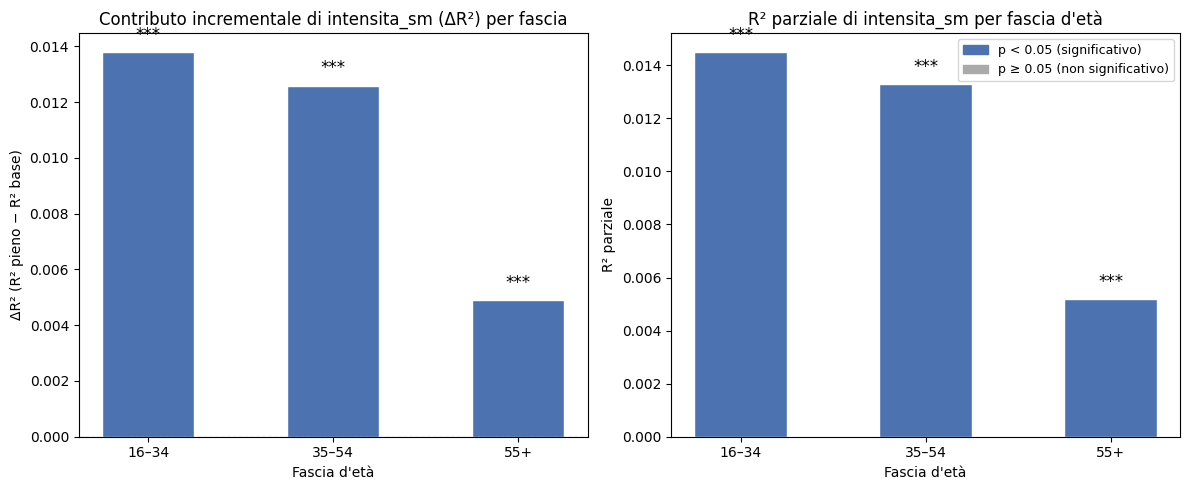

Salvato: output/figures/step4_confronto_modelli.png


In [12]:
# ============================================================
# STEP 4 — Confronto modelli annidati + R² parziale
# Social Media Use and Loneliness in Europe: Does Age Matter?
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from matplotlib.patches import Patch
 
pd.set_option('display.float_format', '{:.4f}'.format)
 
# ------------------------------------------------------------------
# 4.1  CARICAMENTO
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                   categories=['16–34', '35–54', '55+'],  # ← MODIFICATO
                                   ordered=True)
df['intensita_sm2'] = df['intensita_sm'] ** 2
print(f"Dataset: {df.shape[0]} righe · {df['paese'].nunique()} paesi")
 
# ------------------------------------------------------------------
# 4.2  DEFINIZIONE MODELLI
# ------------------------------------------------------------------
formula_base = 'score_UCLA ~ sesso + education + income + C(paese)'
formula_full = ('score_UCLA ~ intensita_sm + intensita_sm2 '
                '+ sesso + education + income + C(paese)')
 
# ------------------------------------------------------------------
# 4.3  CONFRONTO MODELLI — TUTTO IL CAMPIONE
# ------------------------------------------------------------------
m_base = smf.ols(formula_base, data=df).fit(cov_type='HC3')
m_full = smf.ols(formula_full, data=df).fit(cov_type='HC3')
 
r2_base  = m_base.rsquared
r2_full  = m_full.rsquared
delta_r2 = r2_full - r2_base
 
n      = int(m_full.nobs)
k_full = m_full.df_model
f_stat = ((r2_full - r2_base) / 2) / ((1 - r2_full) / (n - k_full - 1))
f_pval = 1 - stats.f.cdf(f_stat, 2, n - k_full - 1)
 
print("\n=== Confronto modelli — tutto il campione ===")
print(f"R² modello base (solo controlli) : {r2_base:.4f}")
print(f"R² modello pieno (+ intensita_sm): {r2_full:.4f}")
print(f"ΔR²                              : {delta_r2:.4f} ({delta_r2*100:.2f}%)")
print(f"F-test contributo intensita_sm   : F = {f_stat:.2f}  p = {f_pval:.4f}")
 
r2_parziale = (r2_full - r2_base) / (1 - r2_base)
print(f"\nR² parziale di intensita_sm      : {r2_parziale:.4f} ({r2_parziale*100:.2f}%)")
 
# ------------------------------------------------------------------
# 4.4  CONFRONTO MODELLI — PER FASCIA D'ETÀ
# ------------------------------------------------------------------
fasce = ['16–34', '35–54', '55+']                                    # ← MODIFICATO
risultati_confronto = []
 
print("\n=== Confronto modelli per fascia d'età ===")
for fascia in fasce:
    sub = df[df['fascia_eta'] == fascia].copy()
    n_f = len(sub)
 
    mb = smf.ols(formula_base, data=sub).fit(cov_type='HC3')
    mf = smf.ols(formula_full, data=sub).fit(cov_type='HC3')
 
    r2_b = mb.rsquared
    r2_f = mf.rsquared
    dr2  = r2_f - r2_b
    r2_p = (r2_f - r2_b) / (1 - r2_b)
 
    k_f  = mf.df_model
    f_s  = ((r2_f - r2_b) / 2) / ((1 - r2_f) / (n_f - k_f - 1))
    f_p  = 1 - stats.f.cdf(f_s, 2, n_f - k_f - 1)
    sig  = '***' if f_p<0.001 else ('**' if f_p<0.01 else ('*' if f_p<0.05 else 'n.s.'))
 
    risultati_confronto.append({
        'fascia'      : fascia,
        'N'           : n_f,
        'R²_base'     : round(r2_b, 4),
        'R²_pieno'    : round(r2_f, 4),
        'ΔR²'         : round(dr2, 4),
        'R²_parziale' : round(r2_p, 4),
        'F'           : round(f_s, 2),
        'p_value'     : round(f_p, 4),
        'sig'         : sig
    })
 
    print(f"\n  Fascia {fascia}  (N={n_f})")
    print(f"    R² base → pieno : {r2_b:.4f} → {r2_f:.4f}  (ΔR² = {dr2:.4f})")
    print(f"    R² parziale     : {r2_p:.4f} ({r2_p*100:.2f}%)")
    print(f"    F-test          : F = {f_s:.2f}  p = {f_p:.4f}  {sig}")
 
tab = pd.DataFrame(risultati_confronto)
tab.to_csv('output/dataset/step4_confronto_modelli.csv', index=False)
print("\nSalvato: output/dataset/step4_confronto_modelli.csv")
 
# ------------------------------------------------------------------
# 4.5  VERIFICA H₀ / H₁
# ------------------------------------------------------------------
print("\n=== Verifica ipotesi (confronto modelli) ===")
print("H₀: intensita_sm non aggiunge potere esplicativo in nessuna fascia")
print("H₁: intensita_sm aggiunge potere esplicativo e in misura variabile per fascia\n")
 
for r in risultati_confronto:
    esito = ("→ contributo SIGNIFICATIVO (contro H₀)"
             if r['p_value'] < 0.05
             else "→ contributo NON significativo (a favore H₀)")
    print(f"  {r['fascia']:6s}  ΔR²={r['ΔR²']:.4f}  R²parz={r['R²_parziale']:.4f}"
          f"  p={r['p_value']:.4f} {r['sig']}  {esito}")
 
# ------------------------------------------------------------------
# 4.6  GRAFICI
# ------------------------------------------------------------------
colori_sig = ['#4C72B0' if r['p_value'] < 0.05 else '#AAAAAA'
              for r in risultati_confronto]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Fig A: ΔR² per fascia
delta_vals = [r['ΔR²'] for r in risultati_confronto]
bars = axes[0].bar(fasce, delta_vals, color=colori_sig, edgecolor='white', width=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title("Contributo incrementale di intensita_sm (ΔR²) per fascia")
axes[0].set_xlabel("Fascia d'età")
axes[0].set_ylabel('ΔR² (R² pieno − R² base)')
for bar, r in zip(bars, risultati_confronto):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0003,
                 r['sig'], ha='center', va='bottom', fontsize=12)
 
# Fig B: R² parziale per fascia
rp_vals = [r['R²_parziale'] for r in risultati_confronto]
bars2 = axes[1].bar(fasce, rp_vals, color=colori_sig, edgecolor='white', width=0.5)
axes[1].set_title("R² parziale di intensita_sm per fascia d'età")
axes[1].set_xlabel("Fascia d'età")
axes[1].set_ylabel('R² parziale')
for bar, r in zip(bars2, risultati_confronto):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0003,
                 r['sig'], ha='center', va='bottom', fontsize=12)
 
legenda = [Patch(color='#4C72B0', label='p < 0.05 (significativo)'),
           Patch(color='#AAAAAA', label='p ≥ 0.05 (non significativo)')]
axes[1].legend(handles=legenda, fontsize=9)
 
plt.tight_layout()
fig.savefig('output/figures/step4_confronto_modelli.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4_confronto_modelli.png")

Dataset: 22962 righe · 31 feature totali

RIEPILOGO STEP 4 — Feature Importance

--- Metriche RF per fascia ---
  16–34   N_train=5248  N_test=1313  MAE=1.4730  RMSE=1.7772
  35–54   N_train=8163  N_test=2041  MAE=1.5256  RMSE=1.8015
  55+     N_train=4957  N_test=1240  MAE=1.4131  RMSE=1.7180

--- Permutation importance per fascia (top 5) ---

  Fascia 16–34  (social_media rank #1):
    social_media            0.0921 ◄
    income                  0.0317
    education               0.0113
    sesso                   0.0033
    paese_14                0.0025

  Fascia 35–54  (social_media rank #1):
    social_media            0.1296 ◄
    income                  0.0589
    paese_26                0.0032
    sesso                   0.0028
    paese_8                 0.0027

  Fascia 55+  (social_media rank #2):
    income                  0.0653
    social_media            0.0410 ◄
    sesso                   0.0097
    paese_20                0.0038
    paese_4                 0.0031

-

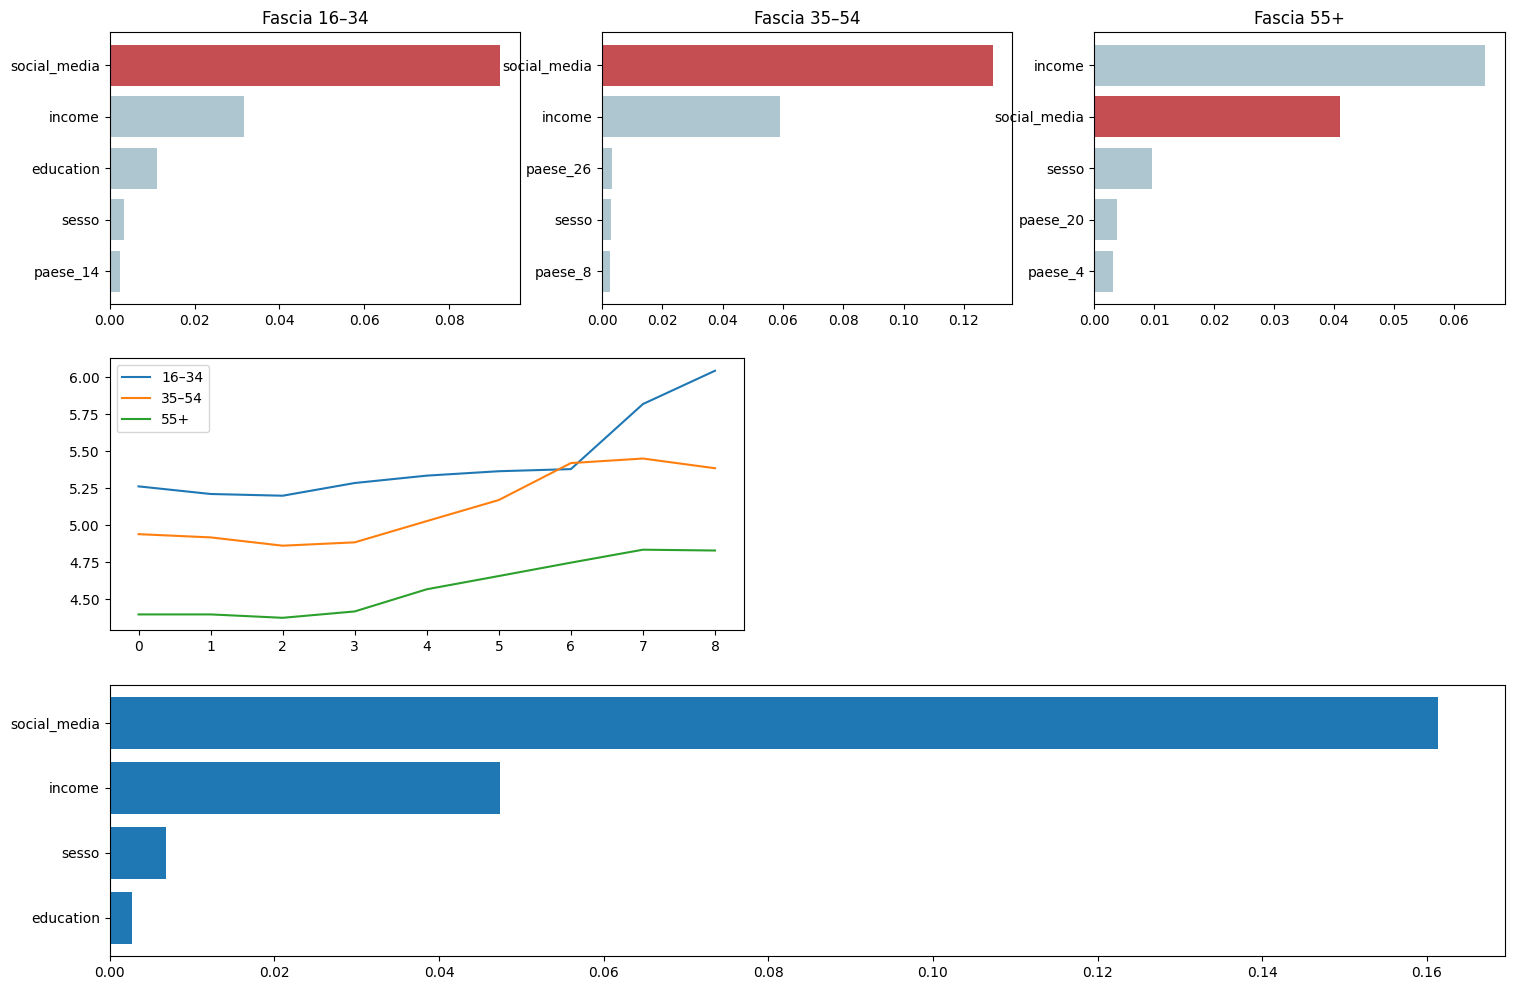

Salvato: output/figures/step4_rf.png


In [13]:
# ============================================================
# STEP 4 — Random Forest (ML supervisionato)
# Does Social Media Use Reduce Loneliness?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

# ------------------------------------------------------------------
# FUNZIONE — Permutation importance a blocchi
# ------------------------------------------------------------------
def perm_importance_group(model, X, y, cols, n_repeats=10):
    baseline = mean_squared_error(y, model.predict(X))
    importances = []

    for _ in range(n_repeats):
        X_perm = X.copy()
        idx = np.random.permutation(len(X_perm))
        X_perm[cols] = X_perm[cols].iloc[idx].values
        perm_score = mean_squared_error(y, model.predict(X_perm))
        importances.append(perm_score - baseline)

    return np.mean(importances)

# ------------------------------------------------------------------
# 4.1  CARICAMENTO E PREPARAZIONE FEATURE
# ------------------------------------------------------------------
df = pd.read_csv('output/dataset/eu_ls_clean.csv')
df['fascia_eta'] = pd.Categorical(df['fascia_eta'],
                                  categories=['16–34', '35–54', '55+'],
                                  ordered=True)

df['intensita_sm2'] = df['intensita_sm'] ** 2

paese_dummies = pd.get_dummies(df['paese'], prefix='paese', drop_first=True)

FEATURES = ['intensita_sm', 'intensita_sm2', 'sesso', 'education', 'income']
X_base   = pd.concat([df[FEATURES], paese_dummies], axis=1).astype(float)
y        = df['score_UCLA']

fasce  = ['16–34', '35–54', '55+']
colori = {'16–34': '#4C72B0', '35–54': '#DD8452', '55+': '#55A868'}

print(f"Dataset: {df.shape[0]} righe · {X_base.shape[1]} feature totali")

# ------------------------------------------------------------------
# 4.2  MODELLO RF — TUTTO IL CAMPIONE
# ------------------------------------------------------------------
X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    X_base, y, test_size=0.20, random_state=42)

rf_full = RandomForestRegressor(
    n_estimators=200, max_features='sqrt',
    min_samples_leaf=20, random_state=42, n_jobs=-1)

rf_full.fit(X_tr_full, y_tr_full)

# ------------------------------------------------------------------
# 4.3  MODELLO RF — PER FASCIA
# ------------------------------------------------------------------
modelli  = {}
perm_imp = {}

for fascia in fasce:
    mask = df['fascia_eta'] == fascia
    X_f  = X_base[mask].reset_index(drop=True)
    y_f  = y[mask].reset_index(drop=True)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_f, y_f, test_size=0.20, random_state=42)

    rf = RandomForestRegressor(
        n_estimators=200, max_features='sqrt',
        min_samples_leaf=20, random_state=42, n_jobs=-1)

    rf.fit(X_tr, y_tr)
    modelli[fascia] = (rf, X_tr, X_te, y_tr, y_te)

    # IMPORTANCE CLASSICA
    perm = permutation_importance(
        rf, X_te, y_te, n_repeats=10, random_state=42, n_jobs=-1)

    imp_series = pd.Series(perm.importances_mean, index=X_base.columns)

    # IMPORTANCE AGGREGATA SOCIAL
    imp_social = perm_importance_group(
        rf, X_te, y_te, ['intensita_sm', 'intensita_sm2']
    )

    imp_series = imp_series.drop(['intensita_sm', 'intensita_sm2'])
    imp_series['social_media'] = imp_social

    perm_imp[fascia] = imp_series

# ------------------------------------------------------------------
# 4.6  GRAFICI
# ------------------------------------------------------------------
fig = plt.figure(figsize=(18, 12))

# Fila 1
for idx, fascia in enumerate(fasce):
    ax   = fig.add_subplot(3, 3, idx + 1)
    top5 = perm_imp[fascia].nlargest(5).sort_values()

    colors = ['#C44E52' if 'social_media' in f else '#AEC6CF'
              for f in top5.index]

    ax.barh(top5.index, top5.values, color=colors)
    ax.set_title(f'Fascia {fascia}')

# PDP invariato
ax_pdp = fig.add_subplot(3, 2, 3)
for fascia in fasce:
    rf, _, X_te, _, _ = modelli[fascia]
    vals = []
    for v in range(9):
        X_tmp = X_te.copy()
        X_tmp['intensita_sm'] = v
        X_tmp['intensita_sm2'] = v**2
        vals.append(rf.predict(X_tmp).mean())
    ax_pdp.plot(range(9), vals, label=fascia)

ax_pdp.legend()

# IMPORTANCE FULL
ax_all = fig.add_subplot(3, 1, 3)

perm_full = permutation_importance(
    rf_full, X_te_full, y_te_full, n_repeats=10, random_state=42, n_jobs=-1)

imp_full = pd.Series(perm_full.importances_mean, index=X_base.columns)

imp_social_full = perm_importance_group(
    rf_full, X_te_full, y_te_full, ['intensita_sm', 'intensita_sm2']
)

imp_full = imp_full.drop(['intensita_sm', 'intensita_sm2'])
imp_full['social_media'] = imp_social_full

imp_individuale = imp_full[['social_media', 'sesso', 'education', 'income']].sort_values()

ax_all.barh(imp_individuale.index, imp_individuale.values)

# ------------------------------------------------------------------
# 4.8  RIEPILOGO FINALE
# ------------------------------------------------------------------
print("\n" + "="*60)
print("RIEPILOGO STEP 4 — Feature Importance")
print("="*60)

# Metriche per fascia
print("\n--- Metriche RF per fascia ---")
for fascia in fasce:
    rf, X_tr, X_te, y_tr, y_te = modelli[fascia]
    y_pred = rf.predict(X_te)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    print(f"  {fascia:6s}  N_train={len(X_tr):4d}  N_test={len(X_te):4d}  MAE={mae:.4f}  RMSE={rmse:.4f}")

# Importance per fascia
print("\n--- Permutation importance per fascia (top 5) ---")
for fascia in fasce:
    top5 = perm_imp[fascia].nlargest(5)
    rank_sm = list(perm_imp[fascia].sort_values(ascending=False).index).index('social_media') + 1
    print(f"\n  Fascia {fascia}  (social_media rank #{rank_sm}):")
    for feat, val in top5.items():
        marker = " ◄" if feat == 'social_media' else ""
        print(f"    {feat:22s}  {val:.4f}{marker}")

# Importance full
print("\n--- Importance tutto il campione ---")
for feat, val in imp_individuale.sort_values(ascending=False).items():
    marker = " ◄" if feat == 'social_media' else ""
    print(f"  {feat:22s}  {val:.4f}{marker}")

# Nota unità
print("\n[NB] Importanze in unità MSE (incremento errore quadratico medio)")
print("     per fascia: permutation su test set; full: test set globale")

plt.tight_layout()
fig.savefig('output/figures/step4_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: output/figures/step4_rf.png")